## VOG Data Visualization

[System] 파일 인코딩 감지 및 스키마 확정 완료: utf-16le


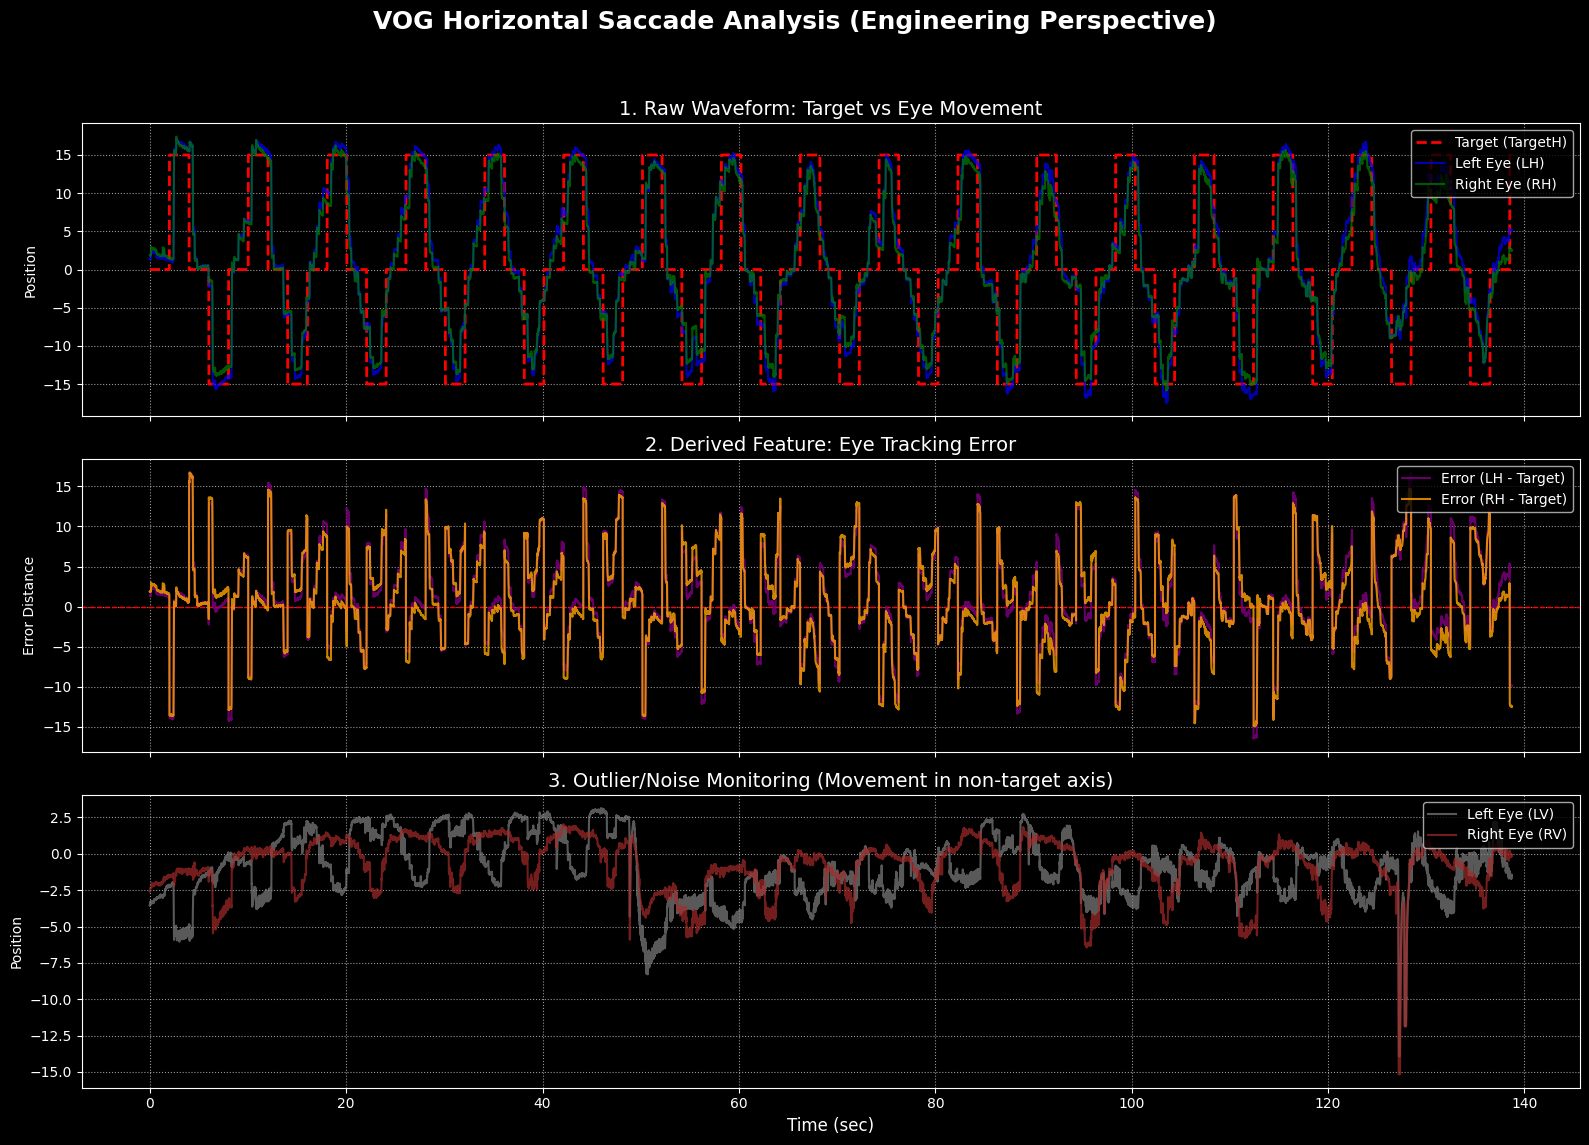

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def visualize_vog_data(file_path):
    """
    VOG 안구 운동 데이터를 로드하고 시스템 아키텍처 설계에 필요한 3가지 핵심 뷰를 시각화합니다.
    (Null Byte 메모리 절단 방지 및 다중 인코딩 자가 치유 파이프라인 적용)
    """
    # 1. 파일 경로 객체화 및 Fail-fast 검증
    path_obj = Path(file_path)
    if not path_obj.exists():
        print(f"[Error] 파일을 찾을 수 없습니다: {path_obj.resolve()}")
        return

    # 2. 커스텀 I/O 데이터 파이프라인 (Multi-Encoding Self-Healing)
    try:
        header_idx = -1
        header_columns = []
        raw_lines = []

        # 단계 1: 진짜 헤더 찾기 (UTF-16, UTF-8 등 인코딩 자가 탐색)
        encodings_to_try = ['utf-16', 'utf-16le', 'utf-8-sig', 'cp949']

        for enc in encodings_to_try:
            try:
                with open(path_obj, 'r', encoding=enc, errors='replace') as f:
                    lines = f.readlines()

                for i, line in enumerate(lines):
                    # UTF-16을 잘못 읽었을 때 발생하는 Null Byte(\x00) 강제 정제 후 검사
                    line_clean = line.replace('\x00', '').lower()
                    if 'lh' in line_clean and 'rh' in line_clean and 'target' in line_clean:
                        header_idx = i
                        raw_lines = lines
                        # 컬럼 추출 및 정제
                        header_columns = [col.replace('\x00', '').strip() for col in line.split(',')]
                        break

                if header_idx != -1:
                    print(f"[System] 파일 인코딩 감지 및 스키마 확정 완료: {enc}")
                    break
            except UnicodeError:
                continue

        if header_idx == -1:
            print("[Error] 파일 내에서 VOG 데이터의 헤더(LH, RH, Target 포함)를 찾을 수 없습니다. (데이터 손상 또는 미지원 포맷)")
            return

        # 단계 2: 순수 파이썬 리스트로 데이터 추출 (Pandas의 간섭 원천 차단 및 Null 정제)
        parsed_data = []
        for line in raw_lines[header_idx + 1:]:
            line_clean = line.replace('\x00', '').strip()
            if not line_clean:  # 빈 줄 건너뛰기
                continue

            row_values = [val.strip() for val in line_clean.split(',')]

            # 장비 오류로 인해 데이터 열 개수가 부족하거나 넘치는 경우, 헤더 기준에 맞춰 안전하게 보정 (Padding/Truncation)
            if len(row_values) < len(header_columns):
                row_values.extend([''] * (len(header_columns) - len(row_values)))
            elif len(row_values) > len(header_columns):
                row_values = row_values[:len(header_columns)]

            parsed_data.append(row_values)

        # 단계 3: 추출된 순수 데이터를 바탕으로 수동으로 DataFrame 조립
        df = pd.DataFrame(parsed_data, columns=header_columns)

        # 모든 문자열 데이터를 수치형(float)으로 안전하게 형변환 (노이즈는 NaN으로)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.dropna(how='all').reset_index(drop=True)

    except Exception as e:
        print(f"[Error] 커스텀 데이터 파싱 중 치명적 오류: {e}")
        return

    # 3. 필수 컬럼 동적 탐색 (초강도 방어적 프로그래밍)
    # 3.1. 시간(Time) 컬럼
    time_col = next((col for col in df.columns if 'time' in str(col).lower() or str(col).lower() == 't'), None)
    if not time_col:
        time_col = df.columns[0]
    time_sec = df[time_col]

    # 3.2. 타겟(Target) 컬럼 탐색
    target_v_col = next((c for c in df.columns if 'targetv' in str(c).lower() or 'target_v' in str(c).lower()), None)
    target_h_col = next((c for c in df.columns if 'targeth' in str(c).lower() or 'target_h' in str(c).lower()), None)

    target_col = None
    if target_v_col and df[target_v_col].abs().sum() > 0:
        target_col = target_v_col
    elif target_h_col:
        target_col = target_h_col
    elif target_v_col:
        target_col = target_v_col

    if not target_col:
        print(f"[Error] 타겟(Target) 컬럼을 찾을 수 없습니다. 인식된 컬럼: {list(df.columns)}")
        return

    direction_str = "Vertical" if 'v' in str(target_col).lower() else "Horizontal"

    # 3.3. 안구 위치(Eye Position) 컬럼 탐색
    search_l = 'lv' if direction_str == "Vertical" else 'lh'
    search_r = 'rv' if direction_str == "Vertical" else 'rh'

    eye_col_l = next((c for c in df.columns if str(c).lower() == search_l), None)
    eye_col_r = next((c for c in df.columns if str(c).lower() == search_r), None)

    if not eye_col_l or not eye_col_r:
        print(f"[Error] 필수 측정 컬럼({search_l}, {search_r}) 누락. 인식된 컬럼: {list(df.columns)}")
        return

    # 4. 파생 변수(Feature) 생성: 오차(Error) = 실제 안구 위치 - 타겟 위치
    df['Error_L'] = df[eye_col_l] - df[target_col]
    df['Error_R'] = df[eye_col_r] - df[target_col]

    # 5. 객체 지향적 플롯(Plot) 설계
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    fig.suptitle(f'VOG {direction_str} Saccade Analysis (Engineering Perspective)', fontsize=18, fontweight='bold')

    # --- [View 1] Raw Signal Tracking ---
    axes[0].plot(time_sec, df[target_col], label=f'Target ({target_col})', color='red', linestyle='--', linewidth=2)
    axes[0].plot(time_sec, df[eye_col_l], label=f'Left Eye ({eye_col_l})', color='blue', alpha=0.7)
    axes[0].plot(time_sec, df[eye_col_r], label=f'Right Eye ({eye_col_r})', color='green', alpha=0.7)
    axes[0].set_title(f'1. Raw Waveform: Target vs Eye Movement', fontsize=14)
    axes[0].set_ylabel('Position')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, linestyle=':', alpha=0.6)

    # --- [View 2] Tracking Error Waveform ---
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[1].plot(time_sec, df['Error_L'], label=f'Error ({eye_col_l} - Target)', color='purple', alpha=0.8)
    axes[1].plot(time_sec, df['Error_R'], label=f'Error ({eye_col_r} - Target)', color='orange', alpha=0.8)
    axes[1].set_title('2. Derived Feature: Eye Tracking Error', fontsize=14)
    axes[1].set_ylabel('Error Distance')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, linestyle=':', alpha=0.6)

    # --- [View 3] Cross-Axis Noise Monitoring ---
    noise_col_l = 'LH' if direction_str == "Vertical" else 'LV'
    noise_col_r = 'RH' if direction_str == "Vertical" else 'RV'

    actual_noise_col_l = next((c for c in df.columns if str(c).lower() == noise_col_l.lower()), None)
    actual_noise_col_r = next((c for c in df.columns if str(c).lower() == noise_col_r.lower()), None)

    if actual_noise_col_l and actual_noise_col_r:
        axes[2].plot(time_sec, df[actual_noise_col_l], label=f'Left Eye ({actual_noise_col_l})', color='gray', alpha=0.7)
        axes[2].plot(time_sec, df[actual_noise_col_r], label=f'Right Eye ({actual_noise_col_r})', color='brown', alpha=0.7)
        axes[2].set_title(f'3. Outlier/Noise Monitoring (Movement in non-target axis)', fontsize=14)
        axes[2].set_xlabel('Time (sec)', fontsize=12)
        axes[2].set_ylabel('Position')
        axes[2].legend(loc='upper right')
        axes[2].grid(True, linestyle=':', alpha=0.6)
    else:
        axes[2].set_title(f'3. Outlier/Noise Monitoring (Data Not Available for {noise_col_l}, {noise_col_r})', fontsize=14)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 실행 엔트리 포인트
if __name__ == "__main__":
    # OS 환경에 구애받지 않는 안전한 상대 경로 객체 생성 예시
    sample_path = Path("data") / "sample_csv" / "HC_csv_24_25" / "20240329_084111_1324721_" / "PD VOG -_Horizontal Saccade A.csv"
    visualize_vog_data(sample_path)